In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df=pd.read_csv("The_ Generative_AI_Ecosystem_50k_User_Reviews_2026.csv")
df.head()

,App,Review_Date,Star_Rating,Review_Text,Word_Count,Review_Length_Chars,Thumbs_Up_Count,App_Version,Sentiment_Polarity,Review_Theme
0,ChatGPT,2026-03-31 12:12:53,5,𝐈 𝐚𝐦 𝐥𝐨𝐯𝐢𝐧𝐠 𝐢𝐭. 𝐈 𝐤𝐧𝐨𝐰𝐚 𝐥𝐨𝐭 𝐨𝐟 𝐭𝐡𝐢𝐧𝐠𝐬 𝐧𝐨𝐰 𝐞𝐚𝐬𝐲...,18,79,0,1.2026.076,0.0000,General
1,ChatGPT,2026-03-31 12:12:16,5,i love this app its very nice and super duper app,11,49,0,1.2026.076,0.9092,General
2,ChatGPT,2026-03-31 12:11:43,1,THIS APP SUCKS THIS SHOULD NEVER EXIST ITS LIT...,17,96,0,1.2026.076,-0.6836,General
3,ChatGPT,2026-03-31 12:10:59,1,“I’m using the ChatGPT Android app with voice ...,81,500,0,1.2026.076,0.5574,General
4,ChatGPT,2026-03-31 12:06:35,5,it has helped me so much in my work that it su...,21,101,0,1.2026.083,0.4404,General


In [4]:
df.tail()

,App,Review_Date,Star_Rating,Review_Text,Word_Count,Review_Length_Chars,Thumbs_Up_Count,App_Version,Sentiment_Polarity,Review_Theme
49995,Claude,2025-05-13 07:22:57,5,best history management option would like org ...,16,97,0,1.250505.27,0.8555,General
49996,Claude,2025-05-13 06:55:43,5,"this app is amazing!! I give it five stars, mo...",30,167,1,1.250505.27,0.9242,General
49997,Claude,2025-05-13 02:51:43,5,it's too good but too much limitation in token...,10,53,0,1.250127.7,-0.2144,General
49998,Claude,2025-05-13 02:16:39,5,The app does what it's supposed to do. It's mi...,72,404,1176,1.250505.27,0.9628,General
49999,Claude,2025-05-13 02:07:25,1,....litterally....crashes after i sign in. ser...,24,130,0,1.250428.17,0.3612,Bugs/Performance


In [5]:
df.describe()

,Star_Rating,Word_Count,Review_Length_Chars,Thumbs_Up_Count,Sentiment_Polarity
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.75532,27.513380,149.318660,1.997980,0.367021
std,1.65465,21.139379,117.363906,40.182453,0.525066
min,1.00000,10.000000,23.000000,0.000000,-0.988400
25%,2.00000,13.000000,69.000000,0.000000,0.000000
50%,5.00000,19.000000,103.000000,0.000000,0.550300
75%,5.00000,33.000000,181.000000,0.000000,0.804700
max,5.00000,192.000000,551.000000,5447.000000,0.999300


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   App                  50000 non-null  object 
 1   Review_Date          50000 non-null  object 
 2   Star_Rating          50000 non-null  int64  
 3   Review_Text          50000 non-null  object 
 4   Word_Count           50000 non-null  int64  
 5   Review_Length_Chars  50000 non-null  int64  
 6   Thumbs_Up_Count      50000 non-null  int64  
 7   App_Version          43088 non-null  object 
 8   Sentiment_Polarity   50000 non-null  float64
 9   Review_Theme         50000 non-null  object 
dtypes: float64(1), int64(4), object(5)
memory usage: 3.8+ MB


In [7]:
df.shape

(50000, 10)

In [8]:
df.isnull().sum()

App                       0
Review_Date               0
Star_Rating               0
Review_Text               0
Word_Count                0
Review_Length_Chars       0
Thumbs_Up_Count           0
App_Version            6912
Sentiment_Polarity        0
Review_Theme              0
dtype: int64

In [9]:
df["App_Version"]=df["App_Version"].fillna("Unknown")

In [10]:
df.isnull().sum()

App                    0
Review_Date            0
Star_Rating            0
Review_Text            0
Word_Count             0
Review_Length_Chars    0
Thumbs_Up_Count        0
App_Version            0
Sentiment_Polarity     0
Review_Theme           0
dtype: int64

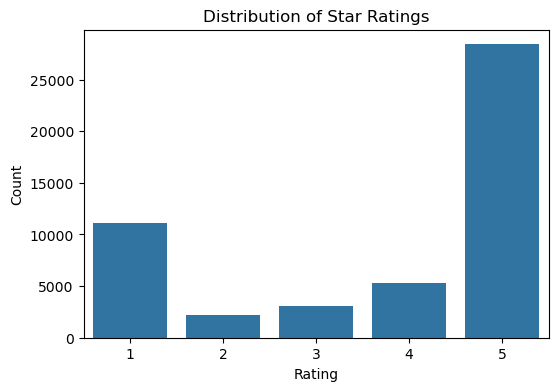

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Star_Rating"])
plt.title("Distribution of Star Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

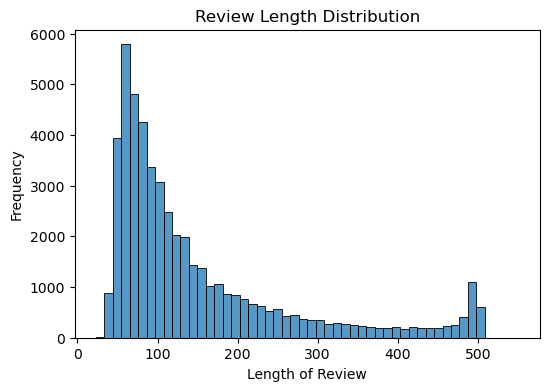

In [12]:
df["review_length"] = df["Review_Text"].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length of Review")
plt.ylabel("Frequency")
plt.show()

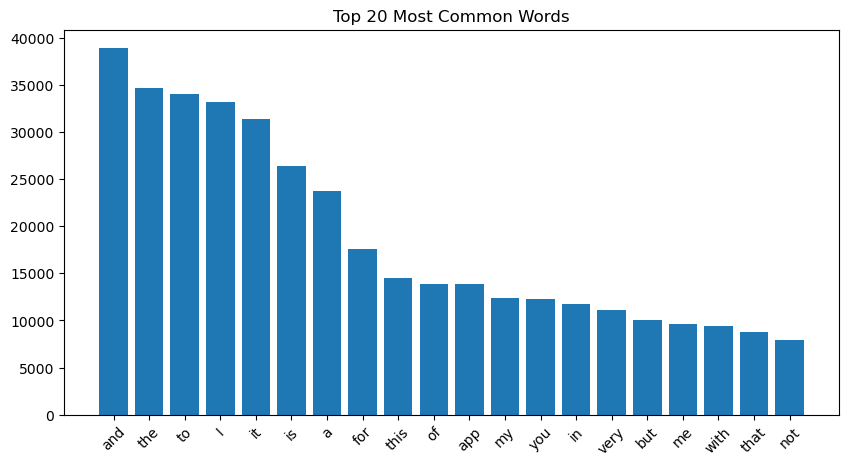

In [14]:
from collections import Counter

all_words = " ".join(df["Review_Text"]).split()
word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Words")
plt.show()

In [15]:
# Target encoding (needed for XGBoost)
le = LabelEncoder()
y = le.fit_transform(df["Star_Rating"])

# Text vectorization (FIT ONLY ONCE)
tfidf = TfidfVectorizer()
x = tfidf.fit_transform(df["Review_Text"])

# Train-test split (ONLY ONCE)
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [16]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

train_scores = []
test_scores = []


===== Logistic Regression =====
Train Accuracy: 0.779975
Test Accuracy: 0.7346

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73      2169
           1       0.30      0.02      0.03       448
           2       0.31      0.07      0.12       597
           3       0.39      0.16      0.23      1028
           4       0.79      0.94      0.86      5758

    accuracy                           0.73     10000
   macro avg       0.49      0.40      0.39     10000
weighted avg       0.67      0.73      0.68     10000



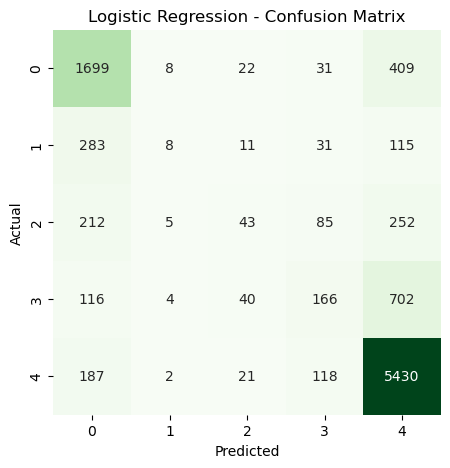


===== Decision Tree =====
Train Accuracy: 0.99985
Test Accuracy: 0.605

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.57      0.56      2169
           1       0.10      0.06      0.08       448
           2       0.11      0.08      0.09       597
           3       0.18      0.16      0.17      1028
           4       0.75      0.79      0.77      5758

    accuracy                           0.60     10000
   macro avg       0.34      0.33      0.33     10000
weighted avg       0.58      0.60      0.59     10000



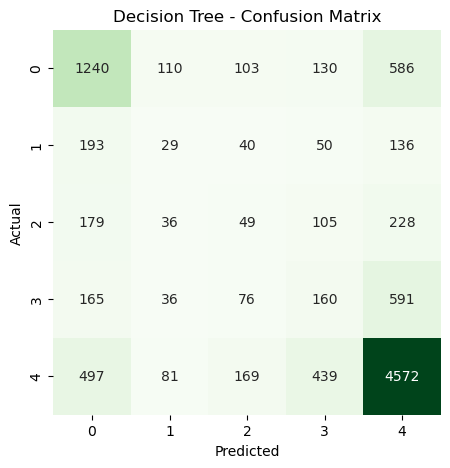


===== XGBoost =====
Train Accuracy: 0.806275
Test Accuracy: 0.7144

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.71      0.69      2169
           1       0.17      0.02      0.03       448
           2       0.24      0.05      0.08       597
           3       0.36      0.13      0.20      1028
           4       0.76      0.94      0.84      5758

    accuracy                           0.71     10000
   macro avg       0.44      0.37      0.37     10000
weighted avg       0.64      0.71      0.66     10000



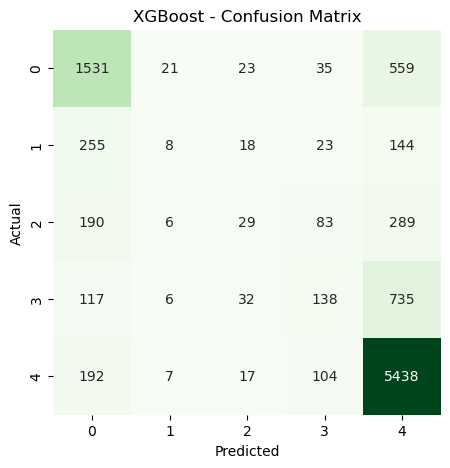

In [17]:
# Training & Evaluation
for name, model in models.items():
    print(f"\n===== {name} =====")

    model.fit(xtrain, ytrain)

    # Predictions
    train_pred = model.predict(xtrain)
    test_pred = model.predict(xtest)

    # Accuracy
    train_acc = accuracy_score(ytrain, train_pred)
    test_acc = accuracy_score(ytest, test_pred)

    train_scores.append(train_acc)
    test_scores.append(test_acc)

    print("Train Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)

    # Classification report
    print("\nClassification Report:\n", classification_report(ytest, test_pred))

    # Confusion matrix
    cm = confusion_matrix(ytest, test_pred)

    plt.figure(figsize=(5,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Extract trained models
lg = models["Logistic Regression"]
dt = models["Decision Tree"]
xg = models["XGBoost"]

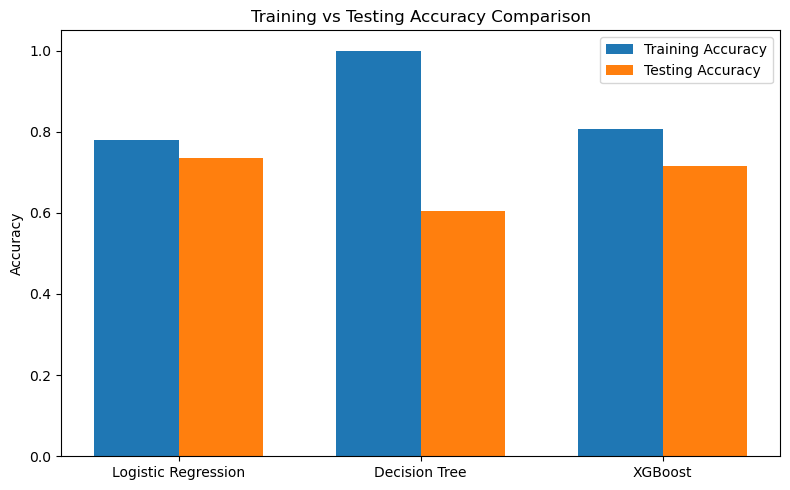

In [18]:
# Comparison Plot
models_names = list(models.keys())

plt.figure(figsize=(8,5))
bar_width = 0.35
x = np.arange(len(models_names))

plt.bar(x - bar_width/2, train_scores, width=bar_width, label='Training Accuracy')
plt.bar(x + bar_width/2, test_scores, width=bar_width, label='Testing Accuracy')

plt.xticks(x, models_names)
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
import gradio as gr

# Function for prediction
def predict_review(review_text):
    # Transform input using SAME TF-IDF
    review_vec = tfidf.transform([review_text])

    # Predictions
    lg_pred = lg.predict(review_vec)[0]
    dt_pred = dt.predict(review_vec)[0]
    xg_pred = xg.predict(review_vec)[0]

    # Convert back to original labels
    lg_pred = le.inverse_transform([lg_pred])[0]
    dt_pred = le.inverse_transform([dt_pred])[0]
    xg_pred = le.inverse_transform([xg_pred])[0]

    return f"""
    Logistic Regression Prediction: ⭐ {lg_pred}
    Decision Tree Prediction: ⭐ {dt_pred}
    XGBoost Prediction: ⭐ {xg_pred}
    """

# Gradio UI
iface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=5, placeholder="Enter a review here..."),
    outputs="text",
    title="⭐ Review Rating Predictor",
    description="Enter a user review and compare predictions from 3 models"
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
